In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
dataset = pd.read_csv(r"C:\Users\matheus_schneider150\Documents\dados_automacao_weg_bruto.csv")
print("---Primeiras linhas do Database Bruto---")
dataset.head()

---Primeiras linhas do Database Bruto---


,ID_EQUIP_CONFUSO,TEMP_VAL_RAW,PRES_PSI_RAW,STATUS_TXT,OP_GENERO_ERR,CONS_KWH_VAL
0,WEG-AUT-1000,80.415499,5.953804,Ativo,M,143.638137
1,WEG-AUT-1001,73.748225,8.526058,Ativo,F,119.283011
2,WEG-AUT-1002,82.000730,6.229241,Manutenção,M,109.098388
3,WEG-AUT-1003,91.191813,6.522981,Ativo,F,106.835740
4,WEG-AUT-1004,72.741390,4.435769,Ativo,M,124.990790


In [56]:
#verificar o tamanho do dataset
print("--\n Tamanho do Dataset bruto--")
print(dataset.shape)

--
 Tamanho do Dataset bruto--
(2150, 6)


In [57]:
dataset.columns = ['id','temperatura','pressao','status','genero','consumo_kwh']

#validar a alteração
dataset.head()

,id,temperatura,pressao,status,genero,consumo_kwh
0,WEG-AUT-1000,80.415499,5.953804,Ativo,M,143.638137
1,WEG-AUT-1001,73.748225,8.526058,Ativo,F,119.283011
2,WEG-AUT-1002,82.000730,6.229241,Manutenção,M,109.098388
3,WEG-AUT-1003,91.191813,6.522981,Ativo,F,106.835740
4,WEG-AUT-1004,72.741390,4.435769,Ativo,M,124.990790


In [58]:
#agrupar e explorar a coluna de status
grupado_status = dataset.groupby(['status']).size()
print("--- Agrupamento por Status--")
print(grupado_status)

--- Agrupamento por Status--
status
Ativo         1527
Manutenção     403
Ocioso         220
dtype: int64


In [59]:
grupado_genero = dataset.groupby(['genero']).size()
print("--- Agrupamento por Status--")
print("--- Agrupamento por Gênero--")

--- Agrupamento por Status--
--- Agrupamento por Gênero--


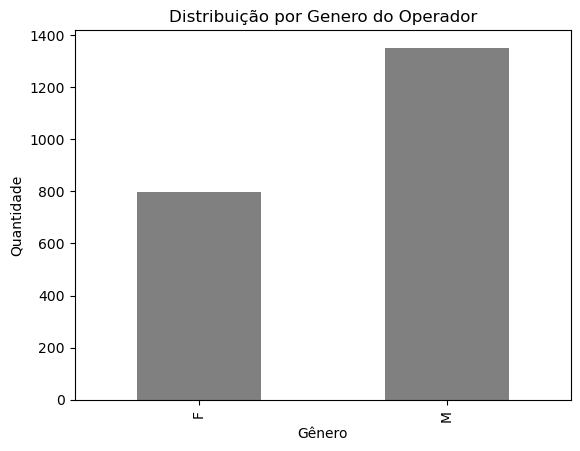

In [60]:
#gerar o grafico de barras na cor cinza para a variavek genero
grupado_genero.plot.bar(color='gray')
plt.title('Distribuição por Genero do Operador')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

In [61]:
# Resumo estatico para identicficar  desvios e anomalias numéracas 
dataset.describe()

,temperatura,pressao,consumo_kwh
count,2105.000000,2100.000000,2150.000000
mean,146.289206,6.466018,120.237563
std,834.958013,3.941850,14.895532
min,41.166693,1.989315,61.163996
25%,68.714655,5.225650,110.544661
50%,75.657826,6.200258,120.296560
75%,82.518021,7.150509,130.093832
max,9999.000000,55.000000,170.660744


In [62]:
#Contamos os valores NAN por coluna 
print("---Valores NAN por coluna ---")
print(dataset.isnull().sum())

---Valores NAN por coluna ---
id              0
temperatura    45
pressao        50
status          0
genero          0
consumo_kwh     0
dtype: int64


In [63]:
#Total de NAN no dataset completo
print(f"\nTotal de NAs inicial: {dataset.isna().sum()}")


Total de NAs inicial: id              0
temperatura    45
pressao        50
status          0
genero          0
consumo_kwh     0
dtype: int64


In [64]:
# Calcular a mediana da pressão 
mediana_pressao = dataset['pressao'].median()
print(mediana_pressao)

6.200258402441996


In [65]:
# Substituir os valores NAN pela mediana 
dataset['pressao'] = dataset['pressao'].fillna(mediana_pressao)

In [66]:
# Vizualizar linhas com dados fora do dominio 
print("--- Registros Fora do Domínio (Temperatura = 9999) ---")
print(dataset[dataset['temperatura'] == 9999.0])

--- Registros Fora do Domínio (Temperatura = 9999) ---
                id  temperatura   pressao      status genero  consumo_kwh
19    WEG-AUT-1019       9999.0  6.852902       Ativo      M    98.529677
66    WEG-AUT-1066       9999.0  5.588592       Ativo      F   115.643378
71    WEG-AUT-1071       9999.0  5.293441       Ativo      M   104.716951
133   WEG-AUT-1133       9999.0  4.826368       Ativo      F   114.574142
247   WEG-AUT-1247       9999.0  4.794460       Ativo      M    99.153298
372   WEG-AUT-1372       9999.0  6.714474       Ativo      M   125.385826
600   WEG-AUT-1600       9999.0  8.657666       Ativo      F    98.637486
846   WEG-AUT-1846       9999.0  6.560854  Manutenção      M   127.904721
878   WEG-AUT-1878       9999.0  5.486271       Ativo      M   116.011199
1037  WEG-AUT-2037       9999.0  7.451177  Manutenção      F   133.272639
1377  WEG-AUT-2377       9999.0  9.095069       Ativo      M   124.534844
1552  WEG-AUT-2552       9999.0  4.917151       Ativo    

In [67]:
#calcular a mediana ignorando os valores espurios e nulos
mediana_temperatura=dataset[(dataset['temperatura'] != 9999.0) & (dataset['temperatura'].notnull())]['temperatura'].median()
print(mediana_temperatura)

75.50713005276046


In [68]:
# Substituir os dados fora do dominio por NaN e depois preencher tudo com a mediana 
dataset['temperatura'] = dataset['temperatura'].replace(9999.0, np.nan)
dataset['temperatura'] = dataset['temperatura'].fillna(mediana_temperatura)

In [69]:
# Verificação se os NANs 
print("\n --- Verificação Final de NANs por Coluna ---")
print(dataset.isnull().sum())
print(f"Total de NAs atual após tratamentos: {dataset.isna().sum().sum()}")


 --- Verificação Final de NANs por Coluna ---
id             0
temperatura    0
pressao        0
status         0
genero         0
consumo_kwh    0
dtype: int64
Total de NAs atual após tratamentos: 0


In [70]:
# Procuramos por duplicados com base na coluna ID 
duplicados_id = dataset[dataset.duplicated(['id'], keep=False)]
print(f"Total de linhas duplicadas encontradas por ID: {len(duplicados_id)}")

Total de linhas duplicadas encontradas por ID: 120


In [71]:
# Excluimos as linhas duplicadas mantendo apenas a primeira ocorrencia 
dataset.drop_duplicates(subset=['id'], keep='first', inplace=True)
print("Duplicados removidos com sucesso!")

Duplicados removidos com sucesso!


In [72]:
#definir um limmite Técnico Máximo para a pressão e substituir outliers pela mediana 
dataset.loc[dataset['pressao'] > 20.0, 'pressao'] = mediana_pressao

In [73]:
#vizualizar a estrutura final do dataset tratado 
print("--- DATASET.HEAD() TRATADO ---")
print(dataset.head())

--- DATASET.HEAD() TRATADO ---
             id  temperatura   pressao      status genero  consumo_kwh
0  WEG-AUT-1000    80.415499  5.953804       Ativo      M   143.638137
1  WEG-AUT-1001    73.748225  8.526058       Ativo      F   119.283011
2  WEG-AUT-1002    82.000730  6.229241  Manutenção      M   109.098388
3  WEG-AUT-1003    91.191813  6.522981       Ativo      F   106.835740
4  WEG-AUT-1004    72.741390  4.435769       Ativo      M   124.990790


In [74]:
import os

# 1. Defina a pasta onde quer salvar (coloque o 'r' antes das aspas)
diretorio = r"C:\Users\matheus_schneider150\Documents"

# 2. Defina o nome do novo arquivo (lembre-se da extensão .csv no final)
nome_arquivo = "dados_automacao_weg_limpo.csv"

# O os.path.join vai juntar tudo certinho
caminho = os.path.join(diretorio, nome_arquivo)

# Salva o arquivo
dataset.to_csv(caminho, index=False)
print(f"Arquivo salvo com sucesso em:\n{caminho}")

Arquivo salvo com sucesso em:
C:\Users\matheus_schneider150\Documents\dados_automacao_weg_limpo.csv
